# 📦 Feature Scaling

> **Folder:** `01_Data_Preprocessing / Feature_Scaling`  
> **Notebook:** `feature_scaling.ipynb`

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand **why** feature scaling is critical for many ML algorithms
- Apply **7 scaling techniques** with real examples
- **Visualize** distribution changes before and after scaling
- Know **which scaler to choose** based on your data characteristics
- Avoid the #1 mistake — **data leakage** from fitting on full data

---

## 📚 Techniques Covered

| # | Technique | Best For |
|---|-----------|----------|
| 1 | Min-Max Scaling | Neural nets, bounded input |
| 2 | Standardization (Z-Score) | General purpose, linear models |
| 3 | Robust Scaling | Data with outliers |
| 4 | MaxAbs Scaling | Sparse data |
| 5 | Log Transformation | Right-skewed features |
| 6 | Power Transformation | Heavy skew, normality needed |
| 7 | Normalizer (per-row) | Text / cosine similarity |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    MaxAbsScaler, Normalizer, PowerTransformer
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Load & Explore Dataset

In [2]:
# ── Synthetic Dataset ────────────────────────────────────────────────────
np.random.seed(42)
n = 300

data = {
    'Age'    : np.random.randint(20, 65, n),
    'Salary' : np.random.randint(25_000, 200_000, n),
    'Score'  : np.random.uniform(0, 100, n),
    'Income' : np.random.exponential(scale=50_000, size=n),  # right-skewed
    'Target' : np.random.randint(0, 2, n),
}

df = pd.DataFrame(data)
feature_cols = ['Age', 'Salary', 'Score', 'Income']

print(f'Shape: {df.shape}')
df.head()

Shape: (300, 5)


,Age,Salary,Score,Income,Target
0,58,111416,48.1667,39137.1103,0
1,48,95271,37.7988,28240.1736,0
2,34,69064,70.5084,20234.4544,0
3,62,132450,24.8724,65568.4616,0
4,27,196890,33.0253,59162.3875,1


In [3]:
# ── Descriptive Statistics ───────────────────────────────────────────────
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,300.0000,42.2067,13.2419,20.0000,30.0000,43.0000,54.0000,64.0000
Salary,300.0000,111297.8967,50570.8101,26062.0000,66469.7500,114684.0000,151149.2500,199358.0000
Score,300.0000,50.0324,28.1064,0.2595,26.4441,51.3447,73.7177,99.7256
Income,300.0000,52085.5822,49822.9060,117.1066,18855.6584,38260.4062,70038.7803,367196.8344


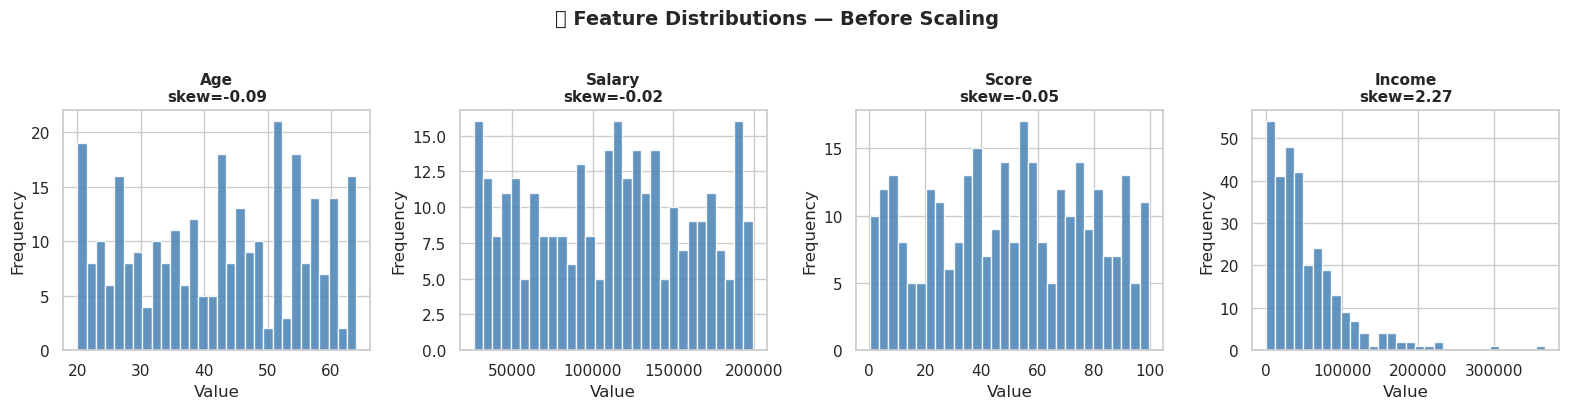

In [4]:
# ── Distribution Before Scaling ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, feature_cols):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'{col}\nskew={df[col].skew():.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('📊 Feature Distributions — Before Scaling', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# ── Train-Test Split (ALWAYS split before scaling!) ──────────────────────
X = df[feature_cols]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print('✅ Split done — scalers will be fit on train only!')

Train: (240, 4) | Test: (60, 4)
✅ Split done — scalers will be fit on train only!


---
## 1️⃣ Min-Max Scaling (Normalization)

> **Formula:** `X_scaled = (X - X_min) / (X_max - X_min)` → Range: **[0, 1]**
>
> ⚠️ Sensitive to outliers — one extreme value compresses all others.

In [6]:
scaler_mm = MinMaxScaler()

X_train_mm = X_train.copy()
X_test_mm  = X_test.copy()

X_train_mm[feature_cols] = scaler_mm.fit_transform(X_train[feature_cols])  # fit on train!
X_test_mm[feature_cols]  = scaler_mm.transform(X_test[feature_cols])       # transform test

print('Min-Max Scaled Train Stats:')
X_train_mm[feature_cols].describe().T[['mean', 'std', 'min', 'max']]

Min-Max Scaled Train Stats:


,mean,std,min,max
Age,0.5093,0.3075,0.0000,1.0000
Salary,0.4996,0.2953,0.0000,1.0000
Score,0.5004,0.2756,0.0000,1.0000
Income,0.1730,0.1575,0.0000,1.0000


---
## 2️⃣ Standardization (Z-Score)

> **Formula:** `X_scaled = (X - μ) / σ` → mean=0, std=1
>
> ✅ The most widely used scaler — good default choice.

In [7]:
scaler_std = StandardScaler()

X_train_std = X_train.copy()
X_test_std  = X_test.copy()

X_train_std[feature_cols] = scaler_std.fit_transform(X_train[feature_cols])
X_test_std[feature_cols]  = scaler_std.transform(X_test[feature_cols])

print(f'Learned mean : {np.round(scaler_std.mean_, 2)}')
print(f'Learned std  : {np.round(scaler_std.scale_, 2)}')

X_train_std[feature_cols].describe().T[['mean', 'std', 'min', 'max']]

Learned mean : [4.2410000e+01 1.1216422e+05 4.9710000e+01 5.2626620e+04]
Learned std  : [1.350000e+01 5.078821e+04 2.718000e+01 4.771059e+04]


,mean,std,min,max
Age,0.0000,1.0021,-1.6595,1.5990
Salary,-0.0000,1.0021,-1.6953,1.6983
Score,0.0000,1.0021,-1.8194,1.8168
Income,0.0000,1.0021,-1.1006,5.2600


---
## 3️⃣ Robust Scaling

> **Formula:** `X_scaled = (X - median) / IQR`
>
> ✅ Best choice when your data has significant outliers.

In [8]:
scaler_rob = RobustScaler()

X_train_rob = X_train.copy()
X_test_rob  = X_test.copy()

X_train_rob[feature_cols] = scaler_rob.fit_transform(X_train[feature_cols])
X_test_rob[feature_cols]  = scaler_rob.transform(X_test[feature_cols])

print(f'Medians : {np.round(scaler_rob.center_, 2)}')
print(f'IQR     : {np.round(scaler_rob.scale_, 2)}')

X_train_rob[feature_cols].describe().T[['mean', 'std', 'min', 'max']]

Medians : [4.300000e+01 1.152200e+05 5.107000e+01 3.962713e+04]
IQR     : [2.400000e+01 8.742700e+04 4.452000e+01 5.502686e+04]


,mean,std,min,max
Age,-0.0247,0.5638,-0.9583,0.8750
Salary,-0.0350,0.5821,-1.0198,0.9517
Score,-0.0304,0.6118,-1.1413,1.0788
Income,0.2362,0.8689,-0.7180,4.7968


---
## 4️⃣ MaxAbs Scaling

> **Formula:** `X_scaled = X / |X_max|` → Range: **[-1, 1]**
>
> ✅ Preserves sparsity — zeros stay zero. Best for sparse matrices.

In [9]:
scaler_ma = MaxAbsScaler()

X_train_ma = X_train.copy()
X_test_ma  = X_test.copy()

X_train_ma[feature_cols] = scaler_ma.fit_transform(X_train[feature_cols])
X_test_ma[feature_cols]  = scaler_ma.transform(X_test[feature_cols])

print(f'Max Abs values: {np.round(scaler_ma.max_abs_, 2)}')
X_train_ma[feature_cols].describe().T[['mean', 'std', 'min', 'max']]

Max Abs values: [6.4000000e+01 1.9842000e+05 9.9090000e+01 3.0358204e+05]


,mean,std,min,max
Age,0.6626,0.2114,0.3125,1.0000
Salary,0.5653,0.2565,0.1313,1.0000
Score,0.5017,0.2749,0.0026,1.0000
Income,0.1734,0.1575,0.0004,1.0000


---
## 5️⃣ Log Transformation

> **Formula:** `X_scaled = log(X + 1)`
>
> ✅ Compresses right-skewed distributions. Only valid for positive values.

Income skewness: 2.2676 → -1.1427


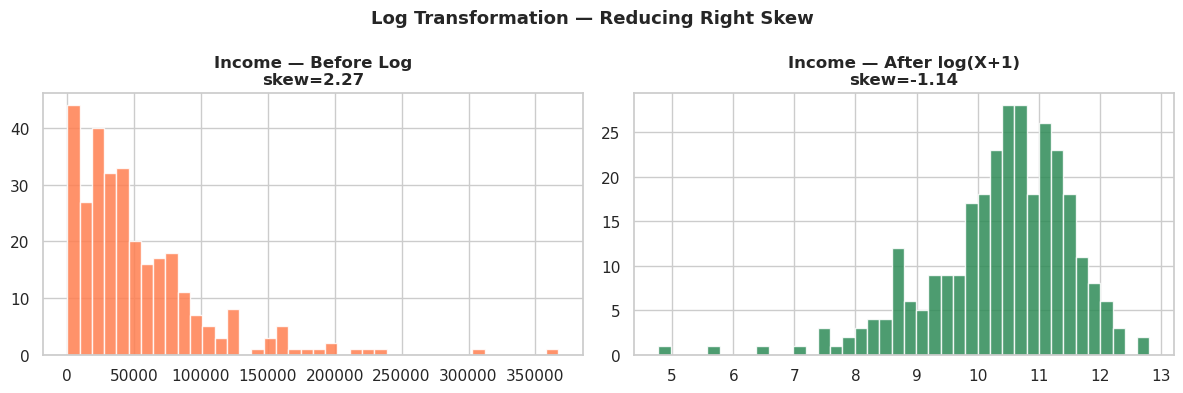

In [10]:
df_log = df.copy()

skew_before = df_log['Income'].skew()
df_log['Income_log'] = np.log1p(df_log['Income'])
skew_after  = df_log['Income_log'].skew()

print(f'Income skewness: {skew_before:.4f} → {skew_after:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_log['Income'], bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Income — Before Log\nskew={skew_before:.2f}', fontweight='bold')

axes[1].hist(df_log['Income_log'], bins=40, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Income — After log(X+1)\nskew={skew_after:.2f}', fontweight='bold')

plt.suptitle('Log Transformation — Reducing Right Skew', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6️⃣ Power Transformation (Yeo-Johnson)

> Automatically finds the best lambda (λ) to make the distribution **most Gaussian**.
>
> ✅ Yeo-Johnson works with zero and negative values (unlike Box-Cox).

In [11]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)

X_train_pt = X_train.copy()
X_test_pt  = X_test.copy()

X_train_pt[feature_cols] = pt.fit_transform(X_train[feature_cols])
X_test_pt[feature_cols]  = pt.transform(X_test[feature_cols])

print(f'Learned lambdas (λ): {dict(zip(feature_cols, np.round(pt.lambdas_, 4)))}')

# ── Compare Skewness ─────────────────────────────────────────────────────
skew_comparison = pd.DataFrame({
    'Feature'         : feature_cols,
    'Skew Before'     : [X_train[c].skew() for c in feature_cols],
    'Skew After (YJ)' : [X_train_pt[c].skew() for c in feature_cols],
}).round(4)

skew_comparison

Learned lambdas (λ): {'Age': 0.9067, 'Salary': 0.783, 'Score': 0.7915, 'Income': 0.3117}


,Feature,Skew Before,Skew After (YJ)
0,Age,-0.0995,-0.1337
1,Salary,-0.0360,-0.1782
2,Score,-0.0421,-0.2645
3,Income,1.7964,-0.0382


---
## 7️⃣ Normalizer (Per-Row Unit Scaling)

> **Formula:** `X_scaled = X / ||X||₂`
>
> ⚠️ Applied **per row** (per sample), NOT per column — unlike all other scalers.

In [12]:
norm = Normalizer(norm='l2')

X_train_norm = X_train.copy()
X_test_norm  = X_test.copy()

X_train_norm[feature_cols] = norm.fit_transform(X_train[feature_cols])
X_test_norm[feature_cols]  = norm.transform(X_test[feature_cols])

# Verify: each row has L2 norm = 1
row_norms = np.linalg.norm(X_train_norm[feature_cols].values, axis=1)
print(f'Row L2 norms (should all be ~1.0): {np.round(row_norms[:5], 4)}')

X_train_norm[feature_cols].head()

Row L2 norms (should all be ~1.0): [1. 1. 1. 1. 1.]


,Age,Salary,Score,Income
232,0.0004,0.9484,0.0005,0.3170
59,0.0002,0.9981,0.0004,0.0611
6,0.0003,0.8546,0.0001,0.5194
185,0.0006,0.7340,0.0010,0.6792
173,0.0011,0.7574,0.0019,0.6530


---
## 📊 8. Visual Comparison — All Scalers Side by Side


📊 Model Accuracy by Scaler:
                     No Scaling  Min-Max  Standardization  Robust
KNN                      0.6333   0.5500           0.5500  0.5333
SVM                      0.5833   0.5167           0.5333  0.5333
Logistic Regression      0.6167   0.6000           0.6000  0.6000


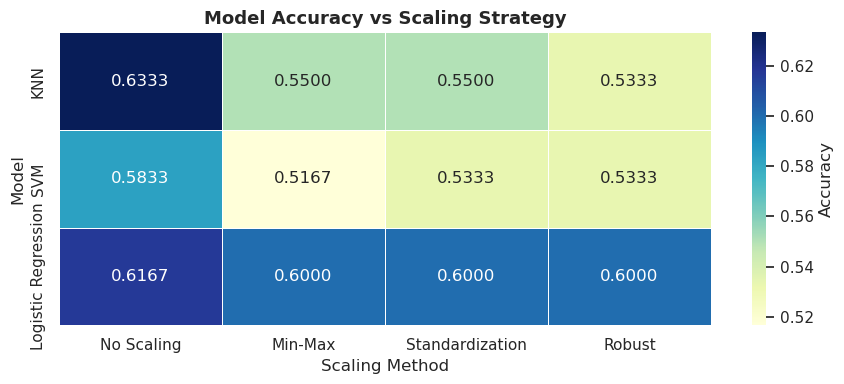

In [14]:
models = {
    'KNN'               : KNeighborsClassifier(n_neighbors=5),
    'SVM'               : SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

datasets = {
    'No Scaling'     : (X_train, X_test),
    'Min-Max'        : (X_train_mm, X_test_mm),
    'Standardization': (X_train_std, X_test_std),
    'Robust'         : (X_train_rob, X_test_rob),
}

results = {}
for model_name, model in models.items():
    results[model_name] = {}
    for scaler_name, (X_tr, X_te) in datasets.items():
        model.fit(X_tr, y_train)
        acc = accuracy_score(y_test, model.predict(X_te))
        results[model_name][scaler_name] = round(acc, 4)

results_df = pd.DataFrame(results).T
print('\n📊 Model Accuracy by Scaler:')
print(results_df.to_string())

# ── Heatmap ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(results_df.astype(float), annot=True, fmt='.4f',
            cmap='YlGnBu', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Accuracy'})
ax.set_title('Model Accuracy vs Scaling Strategy', fontsize=13, fontweight='bold')
ax.set_xlabel('Scaling Method')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

---
## 🔧 10. Using Scalers in Sklearn Pipelines

In [15]:
# ── Pipeline: Scaler + Model ─────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='rbf', random_state=42))
])

pipeline.fit(X_train, y_train)
pipe_acc = accuracy_score(y_test, pipeline.predict(X_test))

print(f'Pipeline (StandardScaler + SVC) Accuracy: {pipe_acc:.4f}')
print('✅ Pipeline ensures scaler is fit on train data only — no leakage!')

Pipeline (StandardScaler + SVC) Accuracy: 0.5333
✅ Pipeline ensures scaler is fit on train data only — no leakage!


---
## ✅ 11. Summary & Best Practices

| Scaler | Formula | Outlier Robust | Best For |
|--------|---------|:--------------:|----------|
| **Min-Max** | (X-min)/(max-min) | ❌ | Neural Nets, bounded input |
| **Standardization** | (X-μ)/σ | ⚠️ | General purpose (default) |
| **Robust** | (X-median)/IQR | ✅ | Data with outliers |
| **MaxAbs** | X/\|max\| | ❌ | Sparse matrices |
| **Log Transform** | log(X+1) | ✅ | Right-skewed features |
| **Power Transform** | Yeo-Johnson | ✅ | Heavy skew, normality needed |
| **Normalizer** | X/\|\|X\|\| | ❌ | Text / cosine similarity |

### 🔑 Golden Rules

1. **Always split first, then scale** — never fit on the full dataset
2. **Fit on train only** — use `.fit_transform(X_train)` and `.transform(X_test)`
3. **Do NOT scale the target variable** (except for some regression output scenarios)
4. **Tree-based models don't need scaling** — Decision Trees, Random Forest, XGBoost
5. **Use Pipelines** — they enforce correct fit/transform order automatically
6. **Check skewness first** — apply Log/Power transform before standardizing skewed features

---

## 🔗 Next Steps

- ➡️ `Outlier_Detection/` — Detect and handle outliers before Min-Max scaling
- ➡️ `Feature_Engineering/` — Create new features, then scale
- ➡️ `03_Supervised_Learning/` — Apply scalers inside full ML Pipelines